In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

import re
import nltk
from nltk.corpus import stopwords

nltk.download('stopwords')

[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\Dell\AppData\Roaming\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


True

In [3]:
df = pd.read_csv(
    "data_science_tweets.csv",
    encoding='ISO-8859-1',
    on_bad_lines='skip',
    low_memory=False
)

In [4]:

df.head()
df.columns

Index(['id', 'conversation_id', 'created_at', 'date', 'time', 'timezone',
       'user_id', 'username', 'name', 'place', 'tweet', 'language', 'mentions',
       'urls', 'photos', 'replies_count', 'retweets_count', 'likes_count',
       'hashtags', 'cashtags', 'link', 'retweet', 'quote_url', 'video',
       'thumbnail', 'near', 'geo', 'source', 'user_rt_id', 'user_rt',
       'retweet_id', 'reply_to', 'retweet_date', 'translate', 'trans_src',
       'trans_dest'],
      dtype='object')

In [5]:
# Select tweet column
df = df[['tweet']]

# Rename for simplicity
df.columns = ['text']

df.head()
df.shape

(241386, 1)

In [6]:
import re
import nltk
from nltk.corpus import stopwords

nltk.download('stopwords')

stop_words = set(stopwords.words('english'))

def clean_text(text):
    text = str(text).lower()
    text = re.sub(r"http\S+|www\S+", "", text)   # remove links
    text = re.sub(r"[^a-z\s]", "", text)         # remove special chars
    words = text.split()
    words = [word for word in words if word not in stop_words]
    return " ".join(words)

df['clean_text'] = df['text'].apply(clean_text)

df[['text','clean_text']].head()

[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\Dell\AppData\Roaming\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


,text,clean_text
0,What can be done? - Never blindly trust an ab...,done never blindly trust abstract press releas...
1,"""We need a paradigm shift from model-centric t...",need paradigm shift modelcentric datacentric m...
2,Using high-resolution satellite data and compu...,using highresolution satellite data computer a...
3,.@Stephenson_Data shares four steps that will ...,stephensondata shares four steps help new data...
4,"""Curricula is inherently brittle in a world wh...",curricula inherently brittle world indemand sk...


In [8]:
!pip install textblob

Defaulting to user installation because normal site-packages is not writeable
   ---------------------------------------- 0.0/625.0 kB ? eta -:--:--
   ---------------------------------------- 0.0/625.0 kB ? eta -:--:--
   ---------------------------------------- 0.0/625.0 kB ? eta -:--:--
   ---------------------------------------- 0.0/625.0 kB ? eta -:--:--
   ---------------- ----------------------- 262.1/625.0 kB ? eta -:--:--
   ---------------- ----------------------- 262.1/625.0 kB ? eta -:--:--
   ---------------- ----------------------- 262.1/625.0 kB ? eta -:--:--
   ---------------- ----------------------- 262.1/625.0 kB ? eta -:--:--
   ---------------- ----------------------- 262.1/625.0 kB ? eta -:--:--
   ---------------- ----------------------- 262.1/625.0 kB ? eta -:--:--
   ------------------------------- ------ 524.3/625.0 kB 231.4 kB/s eta 0:00:01
   ------------------------------- ------ 524.3/625.0 kB 231.4 kB/s eta 0:00:01
   -------------------------------------

In [9]:
!python -m textblob.download_corpora

Finished.


[nltk_data] Downloading package brown to
[nltk_data]     C:\Users\Dell\AppData\Roaming\nltk_data...
[nltk_data]   Package brown is already up-to-date!
[nltk_data] Downloading package punkt_tab to
[nltk_data]     C:\Users\Dell\AppData\Roaming\nltk_data...
[nltk_data]   Package punkt_tab is already up-to-date!
[nltk_data] Downloading package wordnet to
[nltk_data]     C:\Users\Dell\AppData\Roaming\nltk_data...
[nltk_data]   Package wordnet is already up-to-date!
[nltk_data] Downloading package averaged_perceptron_tagger_eng to
[nltk_data]     C:\Users\Dell\AppData\Roaming\nltk_data...
[nltk_data]   Package averaged_perceptron_tagger_eng is already up-to-
[nltk_data]       date!
[nltk_data] Downloading package conll2000 to
[nltk_data]     C:\Users\Dell\AppData\Roaming\nltk_data...
[nltk_data]   Package conll2000 is already up-to-date!
[nltk_data] Downloading package movie_reviews to
[nltk_data]     C:\Users\Dell\AppData\Roaming\nltk_data...
[nltk_data]   Package movie_reviews is already u

In [10]:
from textblob import TextBlob

def get_sentiment(text):
    polarity = TextBlob(text).sentiment.polarity
    if polarity >= 0:
        return 1   # Positive
    else:
        return 0   # Negative

df['sentiment'] = df['clean_text'].apply(get_sentiment)

df[['clean_text','sentiment']].head()

,clean_text,sentiment
0,done never blindly trust abstract press releas...,0
1,need paradigm shift modelcentric datacentric m...,1
2,using highresolution satellite data computer a...,0
3,stephensondata shares four steps help new data...,1
4,curricula inherently brittle world indemand sk...,1


In [11]:
# =========================================
# Convert text → numerical using TF-IDF
# =========================================
from sklearn.feature_extraction.text import TfidfVectorizer

vectorizer = TfidfVectorizer(max_features=5000)

X = vectorizer.fit_transform(df['clean_text'])
y = df['sentiment']

X.shape

(241386, 5000)

In [12]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

X_train.shape, X_test.shape

((193108, 5000), (48278, 5000))

In [14]:
from sklearn.linear_model import LogisticRegression

model = LogisticRegression()
model.fit(X_train, y_train)

,penalty,'l2'
,dual,False
,tol,0.0001
,C,1.0
,fit_intercept,True
,intercept_scaling,1
,class_weight,None
,random_state,None
,solver,'lbfgs'
,max_iter,100
,multi_class,'deprecated'


In [15]:
# =========================================
# Convert text into numerical features
# =========================================
from sklearn.feature_extraction.text import TfidfVectorizer

vectorizer = TfidfVectorizer(max_features=5000)

X = vectorizer.fit_transform(df['clean_text']).toarray()
y = df['sentiment']

X.shape, y.shape

((241386, 5000), (241386,))

In [16]:
# =========================================
# Train Logistic Regression
# =========================================
from sklearn.linear_model import LogisticRegression

model = LogisticRegression()
model.fit(X, y)

# =========================================
# Predictions
# =========================================
y_pred = model.predict(X)

# =========================================
# Evaluation
# =========================================
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

accuracy = accuracy_score(y, y_pred)
accuracy

cm = confusion_matrix(y, y_pred)
cm

print(classification_report(y, y_pred))

              precision    recall  f1-score   support

           0       0.92      0.71      0.80     21347
           1       0.97      0.99      0.98    220039

    accuracy                           0.97    241386
   macro avg       0.95      0.85      0.89    241386
weighted avg       0.97      0.97      0.97    241386



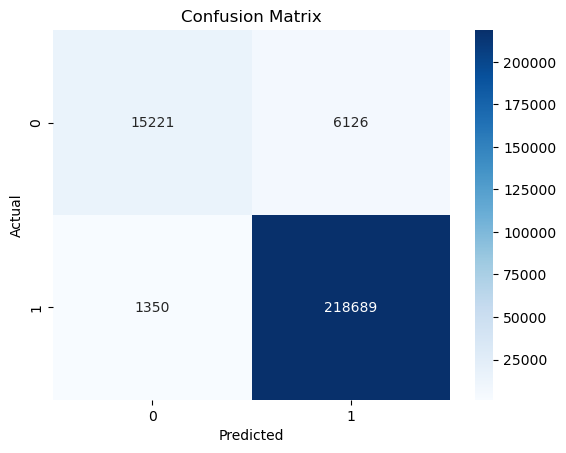

In [17]:
import seaborn as sns
import matplotlib.pyplot as plt

sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.title("Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

In [18]:
# =========================================
# Test Custom Tweet
# =========================================

sample_tweets = [
    "I love data science and machine learning",
    "This is the worst analysis I have ever seen"
]

# Clean the text
sample_clean = [clean_text(text) for text in sample_tweets]

# Convert using same vectorizer
sample_vec = vectorizer.transform(sample_clean)

# Predict
predictions = model.predict(sample_vec)

# Show results
for tweet, pred in zip(sample_tweets, predictions):
    if pred == 1:
        print(f"Tweet: {tweet} → Positive 😊")
    else:
        print(f"Tweet: {tweet} → Negative 😞")

Tweet: I love data science and machine learning → Positive 😊
Tweet: This is the worst analysis I have ever seen → Negative 😞
